In [1]:
%load_ext autoreload
%autoreload 2

In [15]:
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier

from agg import build_all_channel_aggregates, compute_liquidity_signals
from notebook_shared import SharedNotebook
# from notebook_shared_lgbm_early_stopping import SharedNotebook


In [16]:
shd = SharedNotebook(algorithm=LGBMClassifier())
def wrangle(is_train: bool=True):
    df_to_use = pd.DataFrame()
    if is_train:
        shd.read_dataset("Train.csv", is_train=is_train)
        df_to_use = shd.train_df if shd.train_df is not None else pd.DataFrame()
    else:
        shd.read_dataset("Test.csv", is_train=is_train)
        df_to_use = shd.test_df if shd.test_df is not None else pd.DataFrame()

    # Month over month calculations
    running_df = shd.calculate_monthovermonth(["total_value", "highest_amount"])

    # Avg mom calculations (normally calculated inside the notebook)
    # print("Avg mom calculations....")
    # if df_to_use is not None:0780635917-bett
    #     av_mom_df = shd.feature_pipeline.bal_avg_mom_calculations(df_to_use)
    # else:
    #     raise ValueError("dataframe to use is None")

    # running_df = pd.concat([running_df, av_mom_df], axis=1)

    # Removing autocorrelation features
    print("Removing autocorrelation features....")
    shd.remove_correlated_features(running_df)


    # Joining with the existing original dataset
    print("Aggregation, Liquidity signals andJoining with the existing original dataset....")
    train_df = pd.concat([df_to_use, running_df], axis=1)
    out = build_all_channel_aggregates(df_to_use)
    sig = compute_liquidity_signals(df_to_use, out)
    train_df = pd.concat([train_df, sig], axis=1)

    # If there is any numpy infite number raise exception
    if train_df.isin([np.inf, -np.inf]).any().sum():
        raise ValueError("There is any numpy infite number. Algorithm may fail to train.")

    # Remove features defined to be less useful
    print("Removing features defined to be less useful....")
    # shd.define_features_to_remove(train_df)

    return train_df


In [17]:
running_df = wrangle()
running_df.head(2)


Is self.test available:  False
Is it training mode:  True
Is self.test available:  False
Is it training mode:  True
Removing autocorrelation features....
Aggregation, Liquidity signals andJoining with the existing original dataset....
Removing features defined to be less useful....


,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,...,withdraw_share_of_outflow,paybill_share_of_outflow,total_outflow_value,total_inflow_value,outflow_to_inflow_ratio,outflow_channel_entropy,withdraw_active_months,paybill_active_months,withdraw_share_trend,paybill_share_trend
0,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,8,58372.55,...,0.498137,0.325910,332489.28,590474.93,0.563088,1.106951,1,4,0.622915,-0.246824
1,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,0,0.00,...,0.732322,0.126699,884314.06,1286319.71,0.687476,0.838202,6,4,-0.205591,0.143456


In [18]:
from build import ModelPipeline
from sklearn.model_selection import train_test_split

def prepare_df(X, is_train=True):
    if not is_train:
        X_test, _ = shd.feature_pipeline.transform(X, is_train=is_train)
        X_test = X_test.loc[:, ~X_test.columns.duplicated()]
        shd.remove_features_definedby_algorithm_gain(X_test, None)
        # shd.remove_netflow_features(X_test, None)
        shd.find_and_remove_mom_features(X_test)
        return X_test
    else:
        raw_train, raw_val = train_test_split(
            X,
            test_size=0.2,
            stratify=X[shd.feature_pipeline.target_col],
            random_state=42,
        )

        X_train, y_train = shd.feature_pipeline.transform(raw_train)
        print("Xtrain shape: ", X_train.shape, "ytrain shape: ", y_train.shape)
        X_val, y_val = shd.feature_pipeline.transform(raw_val)
        X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

        if y_train is None:
            raise ValueError("y_train is None")
        
        pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

        # Get dulicated columns and remain with one of them
        X_train, X_val = X_train.loc[:, ~X_train.columns.duplicated()], X_val.loc[:, ~X_val.columns.duplicated()]
        shd.remove_features_definedby_algorithm_gain(X_train, X_val)
        # shd.remove_netflow_features(X_train, X_val)
        shd.find_and_remove_mom_features(X_train)
        shd.find_and_remove_mom_features(X_val)
        print("X_train shape: ", X_train.shape, "y_train shape: ", y_train.shape)

        return X_train, y_train, X_val, y_val, pos_weight

In [19]:
X_train, y_train, X_val, y_val, pos_weight = prepare_df(running_df)
X_train.head(2)

/home/eugene/projects/ML/ZINDI - LIQUIDITY STRESS PREDICTION/build.py:518: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["bal_slope_6m"] = self._compute_slopes(data, "daily_avg_bal", months=6)
/home/eugene/projects/ML/ZINDI - LIQUIDITY STRESS PREDICTION/build.py:519: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["bal_slope_3m"] = self._compute_slopes(data, "daily_avg_bal", months=3)
/home/eugene/projects/ML/ZINDI - LIQUIDITY STRESS PREDICTION/build.py:520: PerformanceWarning: DataFrame is highly fragmented.  This is usuall

Xtrain shape:  (32000, 201) ytrain shape:  (32000,)


/home/eugene/projects/ML/ZINDI - LIQUIDITY STRESS PREDICTION/build.py:518: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["bal_slope_6m"] = self._compute_slopes(data, "daily_avg_bal", months=6)
/home/eugene/projects/ML/ZINDI - LIQUIDITY STRESS PREDICTION/build.py:519: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["bal_slope_3m"] = self._compute_slopes(data, "daily_avg_bal", months=3)
/home/eugene/projects/ML/ZINDI - LIQUIDITY STRESS PREDICTION/build.py:520: PerformanceWarning: DataFrame is highly fragmented.  This is usuall

X_train shape:  (32000, 117) y_train shape:  (32000,)


,arpu,age,x_90_d_activity_rate,m1_deposit_total_value,m1_deposit_highest_amount,m2_deposit_total_value,m2_deposit_highest_amount,m3_deposit_total_value,m3_deposit_highest_amount,m4_deposit_total_value,...,mm_received_vol_avg,mm_received_count_avg,mm_received_recent_vs_old_diff,mm_received_hghamt_avg,m4_total_inflow,m4_total_outflow,m5_total_inflow,m5_total_outflow,m6_total_inflow,m6_total_outflow
16946,3187.16,38,0.4573,0.0,0.0,1554.50,984.61,0.00,0.00,0.00,...,13.000000,6.166667,-82.72,4184.595,18347.17,2455.14,10842.32,761.46,0.0,5324.43
39245,4769.99,45,0.5526,0.0,0.0,15183.94,9916.60,37291.16,7779.06,32695.72,...,12.333333,9.166667,2332.59,6210.780,205371.84,21213.79,55905.39,67126.86,4163.3,52634.76


In [24]:
model = shd.tune_lgbm(X_train, y_train, pos_weight=2.3)

(32000, 46) (32000,)
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 3000, 'num_leaves': 15, 'objective': 'binary', 'reg_alpha': 10, 'reg_lambda': 20, 'scale_pos_weight': 2.3}
Best CV Score: 0.9105


In [9]:
# Currently the best settings
# 1.Best Parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 3000, 'num_leaves': 15, 'objective': 'binary', 'reg_alpha': 10, 'reg_lambda': 20, 'scale_pos_weight': 2.3}
# 2.Best Parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 1000, 'num_leaves': 31, 'objective': 'binary', 'reg_alpha': 10, 'reg_lambda': 20, 'scale_pos_weight': 2.3}


In [21]:
# Get model best performing features, sort them in descending order, store in dataframe and export it
best_prams = model.feature_importances_
best_prams = zip(X_train.columns.tolist(), best_prams)
best_prams = pd.DataFrame(best_prams, columns=["feature", "importance"]).sort_values(by="importance", ascending=False)

# Find the relative contribution to the model's performance and export it to a CSV file
best_prams["relative_contribution"] = best_prams["importance"] / best_prams["importance"].sum()
# Cumulative relative contribution
best_prams["cumulative_relative_contribution"] = best_prams["relative_contribution"].cumsum()

best_prams.to_csv("best_prams.csv", index=False)

In [22]:
# Remove cumulative relative contribution which is greater than 0.95
best_prams = best_prams[best_prams["cumulative_relative_contribution"] <= 0.90]
best_prams


,feature,importance,relative_contribution,cumulative_relative_contribution
48,net_coverage_recent_3m,207124.672368,0.166476,0.166476
46,inflow_drift_3m,160741.248842,0.129195,0.295671
87,old3_avg_balance,154509.653843,0.124187,0.419858
49,bal_m1_m6_ratio,55621.792734,0.044706,0.464564
19,m2_daily_avg_bal,53774.014931,0.043221,0.507785
75,recent3_withdraw_agents_ratio,52783.362705,0.042425,0.550209
20,m3_daily_avg_bal,51025.275976,0.041011,0.591221
70,withdraw_agents_hghamt_6m,30538.399038,0.024545,0.615766
23,balance_volatility,29763.433606,0.023922,0.639688
22,balance_trend,27910.501964,0.022433,0.662121


In [23]:
# Re-train the model with the best parameters (features that are stored in best_prams dataframe)
X_train = X_train[best_prams["feature"].tolist()]
X_val = X_val[best_prams["feature"].tolist()]


In [25]:
train_preds, val_preds = shd.run_predictions(model, X_train, X_val, y_train, y_val)

Train ROC:  0.9536028109681374
Val ROC:  0.9078155637254902
Val Log Loss:  0.2652770363784946


Classification report: 
               precision    recall  f1-score   support

           0       0.94      0.94      0.94      6800
           1       0.64      0.64      0.64      1200

    accuracy                           0.89      8000
   macro avg       0.79      0.79      0.79      8000
weighted avg       0.89      0.89      0.89      8000



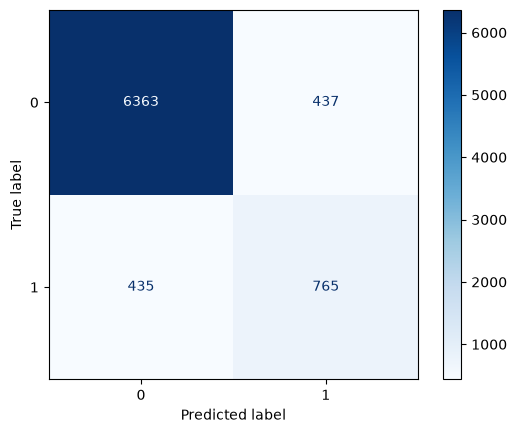

In [26]:
shd.build_cm(y_val, val_preds)

In [27]:
clb_model = shd.calibrate_model(model, X_train, y_train)
val_pred = shd.run_calibrated_predictions(clb_model, X_val)
val_pred

array([0.0166903 , 0.0437964 , 0.80539166, ..., 0.00277292, 0.00773938,
       0.07475284], shape=(8000,))

In [28]:
calibrated_pred = shd.display_val_prediction_stats(val_pred, y_val)

Val ROC:  0.9078757965686275
Val Log Loss:  0.24821937976335837


In [27]:
# Do the same process for test dataframe
shd = SharedNotebook(algorithm=LGBMClassifier(), is_train=False)
test_running_df = wrangle(is_train=False)
test_running_df.shape

Reaing test dataset
Is self.test available:  True
Is it training mode:  False
Is self.test available:  True
Is it training mode:  False
Removing autocorrelation features....
Aggregation, Liquidity signals andJoining with the existing original dataset....
Removing features defined to be less useful....
Is self.test available:  True
Is it training mode:  False
After removing unuseful features:  (30000, 238)


(30000, 238)

In [28]:
set(running_df.columns) - set(test_running_df.columns)

{'liquidity_stress_next_30d'}

In [29]:
X_test = prepare_df(test_running_df, is_train=False)
X_test.head(2)

/home/eugene/projects/ML/ZINDI - LIQUIDITY STRESS PREDICTION/build.py:352: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["bal_slope_6m"] = self._compute_slopes(data, "daily_avg_bal", months=6)
/home/eugene/projects/ML/ZINDI - LIQUIDITY STRESS PREDICTION/build.py:353: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["bal_slope_3m"] = self._compute_slopes(data, "daily_avg_bal", months=3)
/home/eugene/projects/ML/ZINDI - LIQUIDITY STRESS PREDICTION/build.py:354: PerformanceWarning: DataFrame is highly fragmented.  This is usuall

,arpu,age,x_90_d_activity_rate,m1_transfer_from_bank_volume,m1_transfer_from_bank_total_value,m1_transfer_from_bank_highest_amount,m2_transfer_from_bank_volume,m2_transfer_from_bank_total_value,m2_transfer_from_bank_highest_amount,m3_transfer_from_bank_volume,...,merchant_unique_6m,old3_avg_balance,bal_cv_3m,bal_cv_6m,m4_total_inflow,m4_total_outflow,m5_total_inflow,m5_total_outflow,m6_total_inflow,m6_total_outflow
0,2653.88,47,0.6905,4,27009.99,11265.21,0,0.00,0.00,4,...,7.0,13561.640000,0.464655,0.315607,0.00,37099.03,239631.20,119604.59,310939.25,32621.79
1,2653.88,47,0.6905,0,0.00,0.00,1,7803.06,6369.44,0,...,9.5,6922.753333,0.505944,0.491602,158714.38,95076.31,164486.22,234865.29,332731.12,113948.11


In [30]:
set(X_train.columns) - set(X_test.columns)
X_test = X_test[best_prams["feature"].tolist()]


In [31]:
test_pred = shd.run_calibrated_predictions(clb_model, X_test)

In [32]:
shd.save_submission_file(test_running_df, test_pred)

Submission file saved!


,ID,Target
0,ID_ED91AC7A28,0.007261
1,ID_29975A9C7E,0.044765
2,ID_F59CE25650,0.031712
3,ID_E875F68D1A,0.005432
4,ID_2902B1C0D0,0.003399
...,...,...
29995,ID_3C7CF79AEE,0.001744
29996,ID_F1651E73C4,0.005707
29997,ID_FD3F0934CA,0.163280
29998,ID_DA6916D6C7,0.003518


In [71]:
# Save current best model, both calibrated and uncalibrated
shd.save_model(model, "lgbm_model")
shd.save_model(clb_model, "lgbm_calibrated_model")